+-----+-----------+-----------+------------+------------+
|   t |    Exacta |     Euler |   Taylor 2 |   Trapecio |
+=====+===========+===========+============+============+
|   0 | 0.01      | 0.01      |  0.01      |  0.01      |
+-----+-----------+-----------+------------+------------+
|  10 | 0.0296033 | 0.0296227 |  0.0296033 |  0.0296033 |
+-----+-----------+-----------+------------+------------+
|  20 | 0.0488185 | 0.0488566 |  0.0488184 |  0.0488185 |
+-----+-----------+-----------+------------+------------+
|  30 | 0.0676531 | 0.0677091 |  0.0676531 |  0.0676531 |
+-----+-----------+-----------+------------+------------+
|  40 | 0.0861148 | 0.086188  |  0.0861148 |  0.0861148 |
+-----+-----------+-----------+------------+------------+
|  50 | 0.104211  | 0.104301  |  0.104211  |  0.104211  |
+-----+-----------+-----------+------------+------------+

Resultados en p(50):
Exacto: 0.104211
Euler:  0.104301 (Error: 8.97e-05)
Taylor: 0.104211 (Error: 5.98e-08)
Trap:   0.104211 (Err

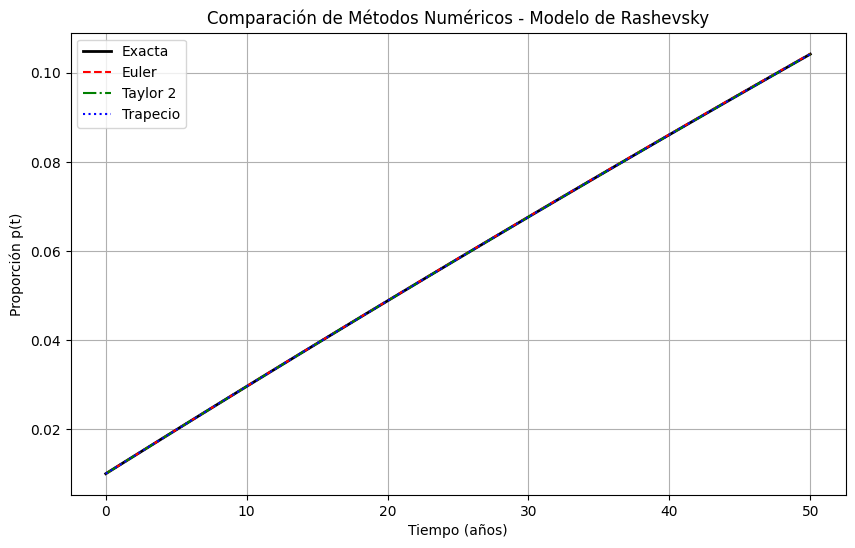

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from tabulate import tabulate # Puedes instalarlo con: pip install tabulate
import timeit

# 1. Parámetros del modelo
p0 = 0.01
b = 0.02
d = 0.015
r = 0.1
h = 1.0
t_final = 50
t_val = np.arange(0, t_final + h, h)
rb = r * b

# 2. Solución Exacta
def p_exacta(t):
    return 1 - (1 - p0) * np.exp(-rb * t)

# 3. Implementación de los Métodos Numéricos
def solve_methods(t_array, h_step):
    n = len(t_array)
    p_euler = np.zeros(n)
    p_taylor = np.zeros(n)
    p_trap = np.zeros(n)
    
    p_euler[0] = p_taylor[0] = p_trap[0] = p0
    
    for i in range(n - 1):
        # Euler Explícito: p_{n+1} = p_n + h*rb*(1 - p_n)
        p_euler[i+1] = p_euler[i] + h_step * rb * (1 - p_euler[i])
        
        # Taylor Orden 2: p_{n+1} = p_n + (h*rb - (h*rb)^2/2) * (1 - p_n)
        p_taylor[i+1] = p_taylor[i] + (h_step * rb - (h_step * rb)**2 / 2) * (1 - p_taylor[i])
        
        # Trapecio Implícito (Despejado): p_{n+1} = (p_n*(1 - hrb/2) + hrb) / (1 + hrb/2)
        term = (h_step * rb) / 2
        p_trap[i+1] = (p_trap[i] * (1 - term) + h_step * rb) / (1 + term)
        
    return p_euler, p_taylor, p_trap

# Ejecución
p_euler, p_taylor, p_trap = solve_methods(t_val, h)
exact_vals = p_exacta(t_val)

# 4. Generación de Tabla de Valores (Muestra cada 10 años)
table_data = []
for i in range(0, len(t_val), 10):
    table_data.append([t_val[i], exact_vals[i], p_euler[i], p_taylor[i], p_trap[i]])

print(tabulate(table_data, headers=["t", "Exacta", "Euler", "Taylor 2", "Trapecio"], tablefmt="grid"))

# 5. Cálculo de Error Absoluto en p(50)
error_euler = abs(exact_vals[-1] - p_euler[-1])
error_taylor = abs(exact_vals[-1] - p_taylor[-1])
error_trap = abs(exact_vals[-1] - p_trap[-1])

print(f"\nResultados en p(50):")
print(f"Exacto: {exact_vals[-1]:.6f}")
print(f"Euler:  {p_euler[-1]:.6f} (Error: {error_euler:.2e})")
print(f"Taylor: {p_taylor[-1]:.6f} (Error: {error_taylor:.2e})")
print(f"Trap:   {p_trap[-1]:.6f} (Error: {error_trap:.2e})")

# 6. Graficación
plt.figure(figsize=(10, 6))
plt.plot(t_val, exact_vals, 'k-', label='Exacta', linewidth=2)
plt.plot(t_val, p_euler, 'r--', label='Euler')
plt.plot(t_val, p_taylor, 'g-.', label='Taylor 2')
plt.plot(t_val, p_trap, 'b:', label='Trapecio')
plt.xlabel('Tiempo (años)')
plt.ylabel('Proporción p(t)')
plt.title('Comparación de Métodos Numéricos - Modelo de Rashevsky')
plt.legend()
plt.grid(True)
plt.show()

In [3]:
import timeit

# Parámetros para el benchmark de alta eficiencia
p0 = 0.01
b = 0.02
r = 0.1
rb = r * b
n_bench = 10**7
h_bench = 50.0 / n_bench

# 1. Función para Benchmarking de Euler Explícito
def benchmark_euler():
    p = p0
    h_rb = h_bench * rb
    for _ in range(n_bench):
        p = p + h_rb * (1 - p)
    return p

# 2. Función para Benchmarking de Taylor de Orden 2
def benchmark_taylor():
    p = p0
    # Precalculamos la constante del esquema de Taylor 2
    factor_taylor = (h_bench * rb) - ((h_bench * rb)**2 / 2)
    for _ in range(n_bench):
        p = p + factor_taylor * (1 - p)
    return p

# 3. Función para Benchmarking del Trapecio Implícito (Despejado)
def benchmark_trapecio():
    p = p0
    hrb_half = (h_bench * rb) / 2
    num_const = h_bench * rb
    den = 1 + hrb_half
    factor_p = 1 - hrb_half
    for _ in range(n_bench):
        # p_{n+1} = (p_n * (1 - hrb/2) + hrb) / (1 + hrb/2)
        p = (p * factor_p + num_const) / den
    return p

# Ejecución y medición de tiempos
print(f"Iniciando Benchmarking con {n_bench:,.0f} iteraciones...\n")

t_euler = timeit.timeit(benchmark_euler, number=1)
t_taylor = timeit.timeit(benchmark_taylor, number=1)
t_trap = timeit.timeit(benchmark_trapecio, number=1)

print(f"{'Método':<20} | {'Tiempo (seg)':<15}")
print("-" * 40)
print(f"{'Euler Explícito':<20} | {t_euler:<15.4f}")
print(f"{'Taylor Orden 2':<20} | {t_taylor:<15.4f}")
print(f"{'Trapecio Implícito':<20} | {t_trap:<15.4f}")

Iniciando Benchmarking con 10,000,000 iteraciones...

Método               | Tiempo (seg)   
----------------------------------------
Euler Explícito      | 1.0167         
Taylor Orden 2       | 1.0127         
Trapecio Implícito   | 0.7231         


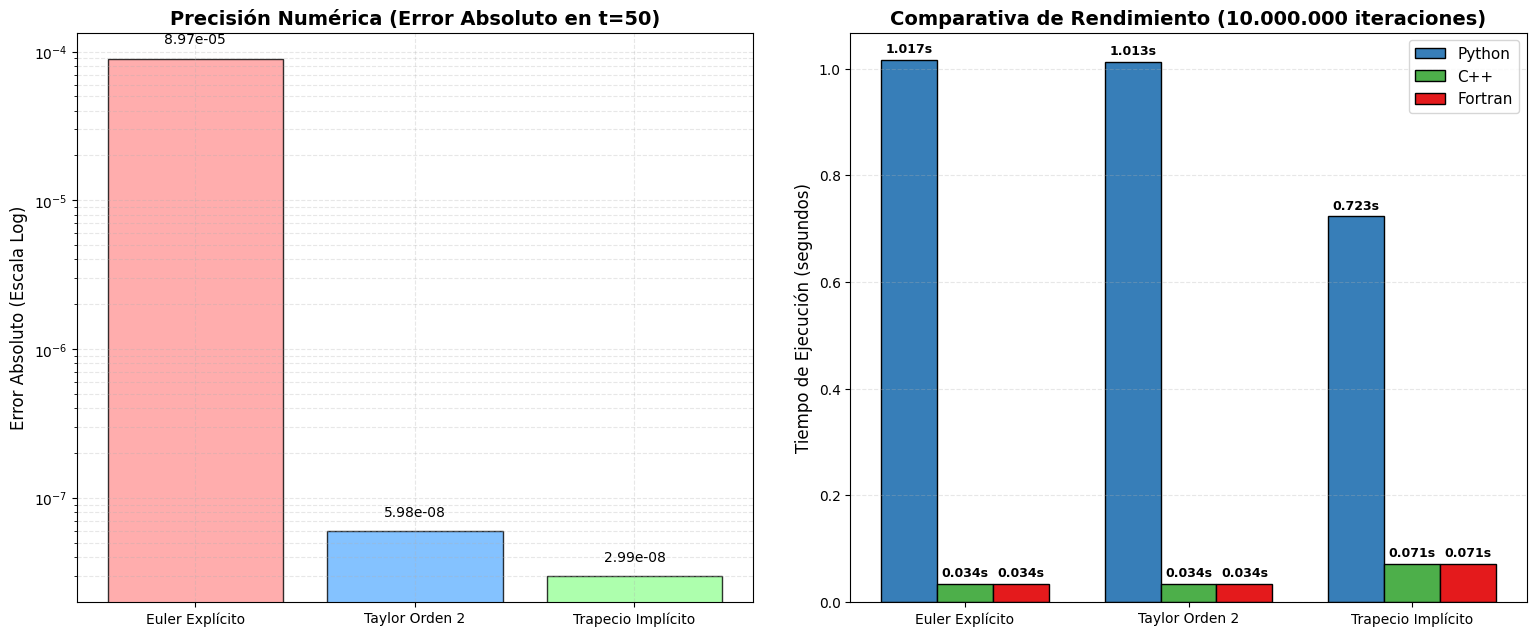

--- RESULTADOS DEL ANÁLISIS ---
Speedup promedio (C++ vs Python): 19.91x
Esto significa que C++ es aprox. 19 veces más rápido que Python en este modelo.


In [1]:
import matplotlib.pyplot as plt
import numpy as np

# --- 1. EXTRACCIÓN DE DATOS (Basado en tus imágenes) ---

# Nombres de los métodos
metodos = ['Euler Explícito', 'Taylor Orden 2', 'Trapecio Implícito']

# Datos de ERROR (Absoluto en t=50)
# Los errores son matemáticamente idénticos en todos los lenguajes
errores = [8.969e-05, 5.981e-08, 2.986e-08]

# Datos de TIEMPO (Segundos para 10^7 iteraciones)
# Extraídos de tus capturas de pantalla
tiempos_python  = [1.0167, 1.0127, 0.7231]
tiempos_cpp     = [0.033805, 0.033577, 0.070867]
tiempos_fortran = [0.0336, 0.0336, 0.0709]

# --- 2. CONFIGURACIÓN DE GRÁFICOS ---
plt.style.use('default') # Estilo limpio
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))

# --- GRÁFICO 1: PRECISIÓN (Escala Logarítmica) ---
colores_error = ['#ff9999', '#66b3ff', '#99ff99']
barras_error = ax1.bar(metodos, errores, color=colores_error, edgecolor='black', alpha=0.8)

ax1.set_yscale('log') # ¡CRUCIAL! Escala logarítmica para ver la diferencia
ax1.set_title('Precisión Numérica (Error Absoluto en t=50)', fontsize=14, fontweight='bold')
ax1.set_ylabel('Error Absoluto (Escala Log)', fontsize=12)
ax1.grid(True, which="both", ls="--", alpha=0.3)

# Etiquetas de valor encima de las barras
for rect in barras_error:
    height = rect.get_height()
    ax1.text(rect.get_x() + rect.get_width()/2., height * 1.2,
             f'{height:.2e}', ha='center', va='bottom', fontsize=10)

# --- GRÁFICO 2: EFICIENCIA COMPUTACIONAL (Benchmark) ---
x = np.arange(len(metodos))
width = 0.25  # Ancho de las barras

# Crear barras agrupadas
rects1 = ax2.bar(x - width, tiempos_python, width, label='Python', color='#377eb8', edgecolor='black')
rects2 = ax2.bar(x, tiempos_cpp, width, label='C++', color='#4daf4a', edgecolor='black')
rects3 = ax2.bar(x + width, tiempos_fortran, width, label='Fortran', color='#e41a1c', edgecolor='black')

ax2.set_title('Comparativa de Rendimiento (10.000.000 iteraciones)', fontsize=14, fontweight='bold')
ax2.set_ylabel('Tiempo de Ejecución (segundos)', fontsize=12)
ax2.set_xticks(x)
ax2.set_xticklabels(metodos)
ax2.legend(fontsize=11)
ax2.grid(True, axis='y', ls="--", alpha=0.3)

# Función para poner etiquetas
def autolabel(rects):
    for rect in rects:
        height = rect.get_height()
        ax2.annotate(f'{height:.3f}s',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3),  # 3 points vertical offset
                    textcoords="offset points",
                    ha='center', va='bottom', rotation=0, fontsize=9, fontweight='bold')

autolabel(rects1)
autolabel(rects2)
autolabel(rects3)

# --- AJUSTES FINALES Y GUARDADO ---
plt.tight_layout(pad=3.0)
plt.savefig('comparativa_final_rashevsky.png', dpi=300)
plt.show()

# --- ANÁLISIS DE SPEEDUP (Impresión en consola) ---
promedio_py = np.mean(tiempos_python)
promedio_cpp = np.mean(tiempos_cpp)
speedup = promedio_py / promedio_cpp

print(f"--- RESULTADOS DEL ANÁLISIS ---")
print(f"Speedup promedio (C++ vs Python): {speedup:.2f}x")
print(f"Esto significa que C++ es aprox. {int(speedup)} veces más rápido que Python en este modelo.")


 TABLA DE RESULTADOS DE SIMULACIÓN (h=1)
+------------+----------+----------+------------+------------+
|   t (años) |   Exacta |    Euler |   Taylor 2 |   Trapecio |
+============+==========+==========+============+============+
|          0 | 0.01     | 0.01     |   0.01     |   0.01     |
+------------+----------+----------+------------+------------+
|          5 | 0.019851 | 0.01986  |   0.019851 |   0.019851 |
+------------+----------+----------+------------+------------+
|         10 | 0.029603 | 0.029623 |   0.029603 |   0.029603 |
+------------+----------+----------+------------+------------+
|         15 | 0.039259 | 0.039288 |   0.039259 |   0.039259 |
+------------+----------+----------+------------+------------+
|         20 | 0.048818 | 0.048857 |   0.048818 |   0.048818 |
+------------+----------+----------+------------+------------+
|         25 | 0.058283 | 0.05833  |   0.058283 |   0.058283 |
+------------+----------+----------+------------+------------+
|         30 

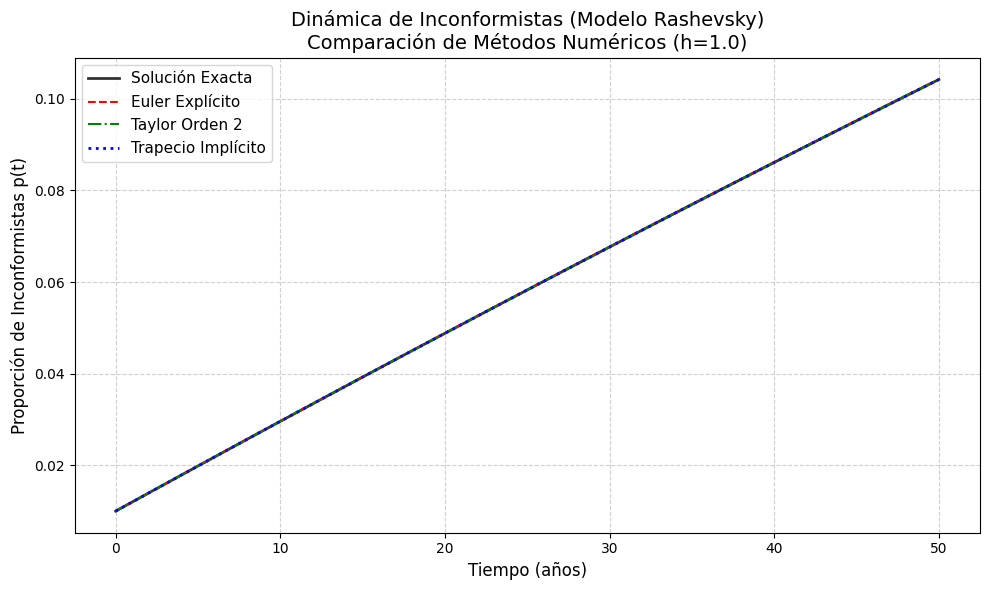

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from tabulate import tabulate 

# ==========================================
# 1. CONFIGURACIÓN Y PARÁMETROS FÍSICOS
# ==========================================
p0 = 0.01          # Proporción inicial de inconformistas (1%)
b = 0.02           # Tasa de natalidad
d = 0.015          # Tasa de mortalidad (Nota: no afecta la ecuación de p(t))
r = 0.1            # Coeficiente de transmisión
h = 1.0            # Paso de tiempo de simulación (1 año)
t_final = 50       # Tiempo final de simulación
rb = r * b         # Constante agrupada para eficiencia

# Vector de tiempo: [0, 1, 2, ..., 50]
t_val = np.arange(0, t_final + h, h)

# ==========================================
# 2. SOLUCIÓN EXACTA (ANALÍTICA)
# ==========================================
def p_exacta(t):
    # Ecuación: p(t) = 1 - (1 - p0) * e^(-rbt)
    return 1 - (1 - p0) * np.exp(-rb * t)

# ==========================================
# 3. IMPLEMENTACIÓN DE MÉTODOS NUMÉRICOS
# ==========================================
def calcular_metodos(tiempo, paso_h):
    n = len(tiempo)
    # Inicializar vectores llenos de ceros
    euler = np.zeros(n)
    taylor = np.zeros(n)
    trap = np.zeros(n)
    
    # Condiciones iniciales
    euler[0] = p0
    taylor[0] = p0
    trap[0] = p0
    
    # Pre-cálculo de factores constantes para optimizar el bucle
    hrb = paso_h * rb
    
    # Factor para Taylor (Orden 2)
    factor_taylor = hrb - (hrb**2 / 2.0)
    
    # Factores para Trapecio (Forma explícita despejada)
    # Fórmula: p_{n+1} = [p_n * (1 - hrb/2) + hrb] / (1 + hrb/2)
    trap_num_mult = 1.0 - (hrb / 2.0)
    trap_num_add = hrb
    trap_den = 1.0 + (hrb / 2.0)

    # Bucle iterativo (Evolución temporal)
    for i in range(n - 1):
        # A. Euler Explícito
        euler[i+1] = euler[i] + hrb * (1 - euler[i])
        
        # B. Taylor Orden 2
        taylor[i+1] = taylor[i] + factor_taylor * (1 - taylor[i])
        
        # C. Trapecio Implícito
        trap[i+1] = (trap[i] * trap_num_mult + trap_num_add) / trap_den
        
    return euler, taylor, trap

# ==========================================
# 4. EJECUCIÓN Y CÁLCULOS
# ==========================================
vals_exacta = p_exacta(t_val)
vals_euler, vals_taylor, vals_trap = calcular_metodos(t_val, h)

# ==========================================
# 5. GENERACIÓN DE TABLA EN CONSOLA
# ==========================================
datos_tabla = []
# Filtramos para mostrar solo cada 5 años y no saturar la pantalla
for i in range(len(t_val)):
    if t_val[i] % 5 == 0: 
        fila = [
            int(t_val[i]), 
            f"{vals_exacta[i]:.6f}", 
            f"{vals_euler[i]:.6f}", 
            f"{vals_taylor[i]:.6f}", 
            f"{vals_trap[i]:.6f}"
        ]
        datos_tabla.append(fila)

headers = ["t (años)", "Exacta", "Euler", "Taylor 2", "Trapecio"]
print("\n" + "="*50)
print(" TABLA DE RESULTADOS DE SIMULACIÓN (h=1)")
print("="*50)
print(tabulate(datos_tabla, headers=headers, tablefmt="grid"))

# ==========================================
# 6. CÁLCULO DE ERRORES EN T=50
# ==========================================
idx_final = -1 # Último índice del array
err_euler = abs(vals_exacta[idx_final] - vals_euler[idx_final])
err_taylor = abs(vals_exacta[idx_final] - vals_taylor[idx_final])
err_trap = abs(vals_exacta[idx_final] - vals_trap[idx_final])

print(f"\n=== ANÁLISIS DE PRECISIÓN EN t={t_final} ===")
print(f"Valor Exacto p(50): {vals_exacta[idx_final]:.8f}")
print("-" * 40)
print(f"Euler Error:  {err_euler:.2e}  (Menos preciso)")
print(f"Taylor Error: {err_taylor:.2e}  (Muy preciso)")
print(f"Trap Error:   {err_trap:.2e}  (Más preciso)")
print("="*50)

# ==========================================
# 7. GRAFICACIÓN
# ==========================================
plt.figure(figsize=(10, 6))

# Graficar líneas
plt.plot(t_val, vals_exacta, 'k-', linewidth=2, alpha=0.8, label='Solución Exacta')
plt.plot(t_val, vals_euler, 'r--', linewidth=1.5, label='Euler Explícito')
plt.plot(t_val, vals_taylor, 'g-.', linewidth=1.5, label='Taylor Orden 2')
plt.plot(t_val, vals_trap, 'b:', linewidth=2, label='Trapecio Implícito')

# Decoración del gráfico
plt.title(f'Dinámica de Inconformistas (Modelo Rashevsky)\nComparación de Métodos Numéricos (h={h})', fontsize=14)
plt.xlabel('Tiempo (años)', fontsize=12)
plt.ylabel('Proporción de Inconformistas p(t)', fontsize=12)
plt.legend(fontsize=11)
plt.grid(True, linestyle='--', alpha=0.6)

# Guardar y mostrar
plt.tight_layout()
plt.savefig('grafico_trayectorias_python.png', dpi=150)
print("\nGráfica guardada exitosamente como 'grafico_trayectorias_python.png'")
plt.show()

+-----+-----------+-----------+-----------+-----------+
|   t |    Exacta |     Euler |    Taylor |      Trap |
+=====+===========+===========+===========+===========+
|   0 | 0.01      | 0.01      | 0.01      | 0.01      |
+-----+-----------+-----------+-----------+-----------+
|  10 | 0.0296033 | 0.0296227 | 0.0296033 | 0.0296033 |
+-----+-----------+-----------+-----------+-----------+
|  20 | 0.0488185 | 0.0488566 | 0.0488184 | 0.0488185 |
+-----+-----------+-----------+-----------+-----------+
|  30 | 0.0676531 | 0.0677091 | 0.0676531 | 0.0676531 |
+-----+-----------+-----------+-----------+-----------+
|  40 | 0.0861148 | 0.086188  | 0.0861148 | 0.0861148 |
+-----+-----------+-----------+-----------+-----------+
|  50 | 0.104211  | 0.104301  | 0.104211  | 0.104211  |
+-----+-----------+-----------+-----------+-----------+


/tmp/ipykernel_3487/607109406.py:120: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()



Gráfica generada: 'grafico_zoom_error.png'


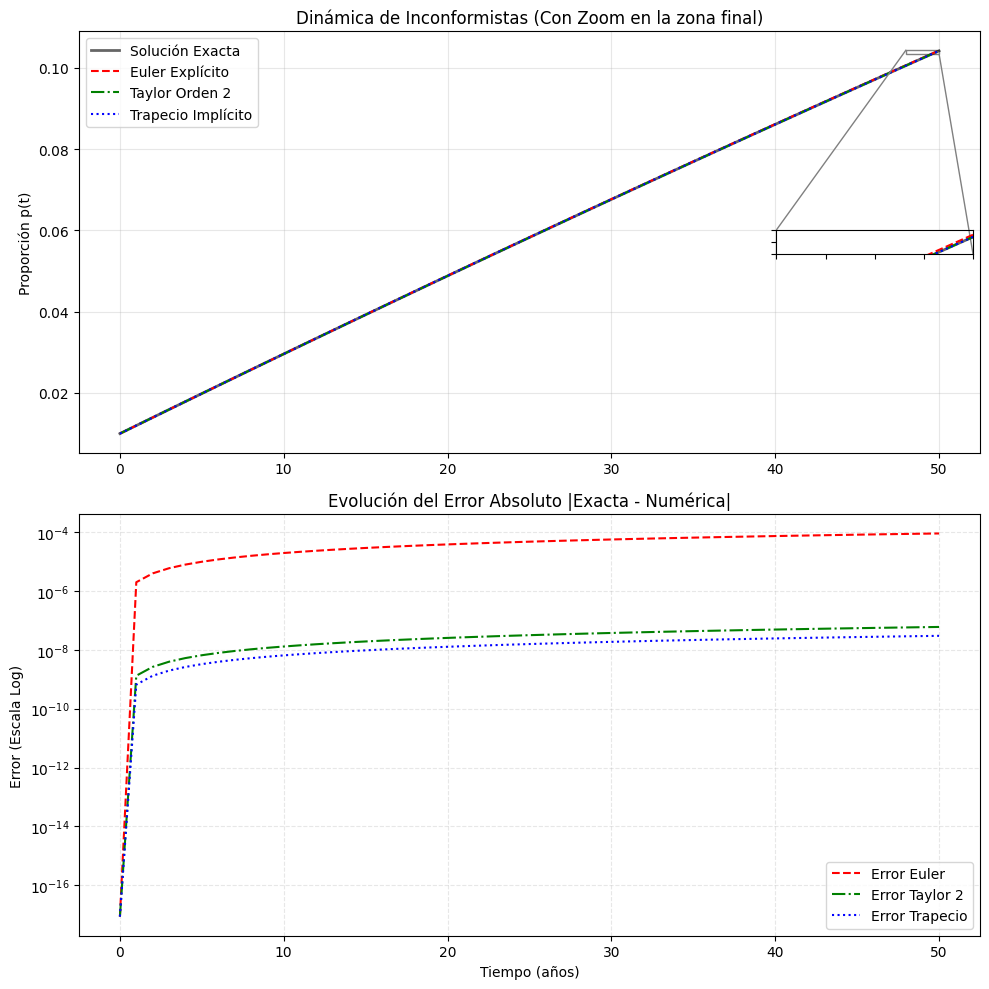

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from tabulate import tabulate 
from mpl_toolkits.axes_grid1.inset_locator import zoomed_inset_axes, mark_inset

# ==========================================
# 1. CONFIGURACIÓN Y PARÁMETROS FÍSICOS
# ==========================================
p0 = 0.01          
b = 0.02           
d = 0.015          
r = 0.1            
h = 1.0            
t_final = 50       
rb = r * b         

t_val = np.arange(0, t_final + h, h)

# ==========================================
# 2. SOLUCIÓN EXACTA
# ==========================================
def p_exacta(t):
    return 1 - (1 - p0) * np.exp(-rb * t)

# ==========================================
# 3. MÉTODOS NUMÉRICOS
# ==========================================
def calcular_metodos(tiempo, paso_h):
    n = len(tiempo)
    euler = np.zeros(n); taylor = np.zeros(n); trap = np.zeros(n)
    euler[0] = p0; taylor[0] = p0; trap[0] = p0
    
    hrb = paso_h * rb
    factor_taylor = hrb - (hrb**2 / 2.0)
    trap_num_mult = 1.0 - (hrb / 2.0)
    trap_num_add = hrb
    trap_den = 1.0 + (hrb / 2.0)

    for i in range(n - 1):
        euler[i+1] = euler[i] + hrb * (1 - euler[i])
        taylor[i+1] = taylor[i] + factor_taylor * (1 - taylor[i])
        trap[i+1] = (trap[i] * trap_num_mult + trap_num_add) / trap_den
        
    return euler, taylor, trap

# ==========================================
# 4. EJECUCIÓN
# ==========================================
vals_exacta = p_exacta(t_val)
vals_euler, vals_taylor, vals_trap = calcular_metodos(t_val, h)

# ==========================================
# 5. TABLA (Igual que antes)
# ==========================================
datos_tabla = []
for i in range(len(t_val)):
    if t_val[i] % 10 == 0 or i == len(t_val)-1: 
        fila = [int(t_val[i]), vals_exacta[i], vals_euler[i], vals_taylor[i], vals_trap[i]]
        datos_tabla.append(fila)

print(tabulate(datos_tabla, headers=["t", "Exacta", "Euler", "Taylor", "Trap"], tablefmt="grid"))

# ==========================================
# 7. GRAFICACIÓN AVANZADA (ZOOM Y ERROR)
# ==========================================
# Creamos una figura con 2 paneles (Arriba: Trayectorias, Abajo: Errores)
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 10))

# --- PANEL 1: TRAYECTORIAS CON ZOOM (LUPA) ---
ax1.plot(t_val, vals_exacta, 'k', linewidth=2, alpha=0.6, label='Solución Exacta')
ax1.plot(t_val, vals_euler, 'r--', label='Euler Explícito')
ax1.plot(t_val, vals_taylor, 'g-.', label='Taylor Orden 2')
ax1.plot(t_val, vals_trap, 'b:', label='Trapecio Implícito')

ax1.set_title('Dinámica de Inconformistas (Con Zoom en la zona final)', fontsize=12)
ax1.set_ylabel('Proporción p(t)')
ax1.legend(loc='upper left')
ax1.grid(True, alpha=0.3)

# --> CREAR EL RECUADRO DE ZOOM (INSET)
# Zoom factor: 6x, Localización: 'center right'
axins = zoomed_inset_axes(ax1, 6, loc='center right') 

# Graficamos lo mismo dentro del recuadro pequeño
axins.plot(t_val, vals_exacta, 'k', linewidth=2, alpha=0.6)
axins.plot(t_val, vals_euler, 'r--')
axins.plot(t_val, vals_taylor, 'g-.')
axins.plot(t_val, vals_trap, 'b:')

# Definimos LÍMITES del zoom (Miramos solo los últimos 2 años)
x1, x2 = 48, 50
y1, y2 = 0.1035, 0.1045 # Ajustado para ver la punta de la curva
axins.set_xlim(x1, x2)
axins.set_ylim(y1, y2)

# Ocultamos las marcas de los ejes del recuadro para limpiar
plt.xticks(visible=False)
plt.yticks(visible=False)

# Dibujamos las líneas que conectan el zoom con la gráfica principal
mark_inset(ax1, axins, loc1=2, loc2=4, fc="none", ec="0.5")

# --- PANEL 2: GRÁFICA DE ERROR (ESCALA LOGARÍTMICA) ---
# Calculamos el error absoluto
err_e = np.abs(vals_exacta - vals_euler)
err_ta = np.abs(vals_exacta - vals_taylor)
err_tr = np.abs(vals_exacta - vals_trap)

# Usamos escala logarítmica porque los errores son muy diferentes (10^-5 vs 10^-8)
ax2.semilogy(t_val, err_e, 'r--', label='Error Euler')
ax2.semilogy(t_val, err_ta, 'g-.', label='Error Taylor 2')
ax2.semilogy(t_val, err_tr, 'b:', label='Error Trapecio')

ax2.set_title('Evolución del Error Absoluto |Exacta - Numérica|', fontsize=12)
ax2.set_xlabel('Tiempo (años)')
ax2.set_ylabel('Error (Escala Log)')
ax2.legend()
ax2.grid(True, which="both", ls="--", alpha=0.3)

plt.tight_layout()
plt.savefig('grafico_zoom_error.png', dpi=150)
print("\nGráfica generada: 'grafico_zoom_error.png'")
plt.show()